# 2D ResNet ECG Classification on PTB-XL

**Model:** Modified ResNet-18 on STFT spectrograms  
**Reference:** *Deep residual 2D convolutional neural network for cardiovascular disease classification*, Nature Scientific Reports, 2024  
**Input:** 1D ECG → Short-Time Fourier Transform → (12, 64, 64) spectrogram image  
**Task:** Multi-label classification — MI, STTC, CD, HYP

## 0 · Install dependencies

In [1]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
try:
    import torch_ecg
except ImportError:
    pip_install('torch-ecg>=0.0.29')
try:
    import sklearn
except ImportError:
    pip_install('scikit-learn')
try:
    import seaborn
except ImportError:
    pip_install('seaborn')
try:
    import scipy
except ImportError:
    pip_install('scipy')
print('Dependencies ready.')

Dependencies ready.


## 1 · Imports & config

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import stft as scipy_stft

from sklearn.metrics import f1_score, multilabel_confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path('.')
PKL_DIR      = Path('../PTB-XL-ECG')
CKPT_DIR     = NOTEBOOK_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

CLASS_NAMES  = ['MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES  = len(CLASS_NAMES)

BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
WARMUP_EPOCHS = 5
THRESHOLD     = 0.5
USE_FOCAL     = True
FOCAL_GAMMA   = 2.0
FOCAL_ALPHA   = 0.25

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}  |  CKPT_DIR: {CKPT_DIR}')

Device: cuda  |  CKPT_DIR: checkpoints


## 2 · Load data

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_train = np.array(load_pkl(PKL_DIR / 'X_train_processed.pickle'), dtype=np.float32).transpose(0,2,1)
y_train = np.array(load_pkl(PKL_DIR / 'y_train_processed.pickle'), dtype=np.float32)
X_val   = np.array(load_pkl(PKL_DIR / 'X_dev_processed.pickle'),   dtype=np.float32).transpose(0,2,1)
y_val   = np.array(load_pkl(PKL_DIR / 'y_dev_processed.pickle'),   dtype=np.float32)
X_test  = np.array(load_pkl(PKL_DIR / 'X_test_processed.pickle'),  dtype=np.float32).transpose(0,2,1)
y_test  = np.array(load_pkl(PKL_DIR / 'y_test_processed.pickle'),  dtype=np.float32)

print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')

Train (17111, 12, 1000)  Val (2156, 12, 1000)  Test (2163, 12, 1000)


## 3 · NORM undersampling & stratified split

In [4]:
# ── Pool & undersample NORM ──────────────────────────────────────────────────
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

NORM_CAP    = 4000
rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
bal_idx = np.concatenate([disease_idx, norm_idx])
X_bal, y_bal = X_all[bal_idx], y_all[bal_idx]

norm_bal = (y_bal.sum(axis=1) == 0)
print(f'Balanced dataset: {len(X_bal)} samples  NORM={norm_bal.sum()} ({100*norm_bal.mean():.1f}%)')

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','iterative-stratification'])
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

norm_col = norm_bal.astype(np.float32).reshape(-1,1)
y_strat  = np.concatenate([y_bal, norm_col], axis=1)

msss1 = MultilabelStratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(msss1.split(X_bal, y_strat))
X_tv, y_tv   = X_bal[tv_idx],   y_bal[tv_idx]
X_test_split = X_bal[test_idx]; y_test_split = y_bal[test_idx]

norm_tv  = (y_tv.sum(axis=1)==0).astype(np.float32).reshape(-1,1)
y_tv_str = np.concatenate([y_tv, norm_tv], axis=1)
msss2 = MultilabelStratifiedShuffleSplit(1, test_size=0.176, random_state=SEED)
tr_idx2, val_idx2 = next(msss2.split(X_tv, y_tv_str))
X_train_split = X_tv[tr_idx2];  y_train_split = y_tv[tr_idx2]
X_val_split   = X_tv[val_idx2]; y_val_split   = y_tv[val_idx2]

print(f'Train {len(X_train_split)} | Val {len(X_val_split)} | Test {len(X_test_split)}')

Balanced dataset: 16347 samples  NORM=4000 (24.5%)
Train 11474 | Val 2424 | Test 2449


## 4 · STFT preprocessing & ECGSpectrogramDataset

In [5]:
def ecg_to_spec(ecg, nperseg=64, noverlap=48, img_size=64):
    """(12,1000) ECG → (12, img_size, img_size) log-magnitude STFT spectrogram."""
    specs = []
    for lead in ecg:
        _, _, Zxx = scipy_stft(lead, nperseg=nperseg, noverlap=noverlap)
        mag = np.log1p(np.abs(Zxx)).astype(np.float32)
        t   = torch.tensor(mag).unsqueeze(0).unsqueeze(0)
        t   = F.interpolate(t, size=(img_size, img_size), mode='bilinear', align_corners=False)
        specs.append(t.squeeze().numpy())
    spec = np.stack(specs).astype(np.float32)
    mn, mx = spec.min(), spec.max()
    return (spec - mn) / (mx - mn + 1e-8)

class ECGSpectrogramDataset(Dataset):
    """Returns (12, H, W) STFT spectrogram + label."""
    def __init__(self, X, y, img_size=64):
        self.X, self.y, self.img_size = X, torch.from_numpy(y), img_size
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        spec = ecg_to_spec(self.X[idx], img_size=self.img_size)
        return torch.from_numpy(spec), self.y[idx]

# Smoke-test
_s, _l = ECGSpectrogramDataset(X_train_split[:4], y_train_split[:4])[0]
print(f'Spectrogram shape: {_s.shape}  dtype: {_s.dtype}')

Spectrogram shape: torch.Size([12, 64, 64])  dtype: torch.float32


## 5 · Loss function

In [6]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

def make_criterion(y_labels):
    if USE_FOCAL:
        return FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
    pos = y_labels.sum(0); neg = len(y_labels) - pos
    pw  = torch.tensor(neg / (pos + 1e-8), dtype=torch.float32).to(DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pw)

criterion = make_criterion(y_train_split)
print(f'Loss: {"Focal" if USE_FOCAL else "Weighted BCE"}')

Loss: Focal


## 6 · Model — 2D ResNet-18

First convolutional layer adapted for 12-channel spectrogram input.

In [7]:
import torchvision.models as tv_models

class ResNet2D_ECG(nn.Module):
    """
    2D ResNet-18 on STFT spectrograms.
    Reference: 'Deep residual 2D convolutional neural network for cardiovascular
    disease classification', Nature Scientific Reports, 2024.
    Input: (N, 12, 64, 64)  Output: logits (N, 4)
    """
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        resnet = tv_models.resnet18(weights=None)
        # Replace first conv: 3 RGB → 12 ECG-lead channels
        resnet.conv1 = nn.Conv2d(12, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Replace head
        resnet.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )
        self.model = resnet

    def forward(self, x):   # returns logits
        return self.model(x)

model = ResNet2D_ECG().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'ResNet2D_ECG  |  params: {total:,}')

ResNet2D_ECG  |  params: 11,206,788


## 7 · Training

In [ ]:
def compute_metrics(probs, targets, threshold=THRESHOLD):
    preds = (probs >= threshold).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    results = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        results[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ('sensitivity','specificity','accuracy','f1'):
        results[f'macro_{m}'] = np.mean([results[c][m] for c in CLASS_NAMES])
    return results

In [9]:
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, n_batches = 0.0, 0
    all_probs, all_targets = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item(); n_batches += 1
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_targets.append(y_b.detach().cpu().numpy())
    return total_loss/n_batches, np.concatenate(all_probs), np.concatenate(all_targets)

IMG_SIZE = 64
tr_loader  = DataLoader(ECGSpectrogramDataset(X_train_split, y_train_split, IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader = DataLoader(ECGSpectrogramDataset(X_val_split,   y_val_split,   IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
te_loader  = DataLoader(ECGSpectrogramDataset(X_test_split,  y_test_split,  IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

best_f1, best_state, no_improve = -1.0, None, 0
history = {'train_loss':[], 'val_loss':[], 'val_f1':[]}

for epoch in range(1, EPOCHS+1):
    tr_loss, _,  _   = run_epoch(tr_loader,  model, criterion, optimizer)
    val_loss, vp, vt = run_epoch(val_loader, model, criterion)
    scheduler.step(val_loss)
    vf1 = compute_metrics(vp, vt)['macro_f1']
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vf1)
    if epoch > WARMUP_EPOCHS:
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save(best_state, CKPT_DIR / 'best_model.pt')
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop at epoch {epoch}  (best val F1={best_f1:.4f})')
            break
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | tr_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_F1={vf1:.4f}')

if best_state:
    model.load_state_dict({k: v.to(DEVICE) for k,v in best_state.items()})

_, test_probs, test_targets = run_epoch(te_loader, model, criterion)
test_metrics = compute_metrics(test_probs, test_targets)

_, val_probs_tune, val_targets_tune = run_epoch(val_loader, model, criterion)
cv_test_probs, cv_test_targets = val_probs_tune, val_targets_tune

print(f'\nTest set ({len(test_probs)} samples):')
print(f'{"Class":<6} {"F1":>8}')
for cls in CLASS_NAMES:
    print(f'  {cls:<5} {test_metrics[cls]["f1"]:.4f}')
print(f'  Macro {test_metrics["macro_f1"]:.4f}')

Epoch   1 | tr_loss=0.0563 | val_loss=0.0492 | val_F1=0.2482
Epoch   5 | tr_loss=0.0391 | val_loss=0.0459 | val_F1=0.5232
Epoch  10 | tr_loss=0.0272 | val_loss=0.0537 | val_F1=0.5281
Epoch  15 | tr_loss=0.0065 | val_loss=0.1120 | val_F1=0.5967
Epoch  20 | tr_loss=0.0006 | val_loss=0.1568 | val_F1=0.5950
Epoch  25 | tr_loss=0.0003 | val_loss=0.1802 | val_F1=0.6048
Epoch  30 | tr_loss=0.0002 | val_loss=0.1903 | val_F1=0.6084
Early stop at epoch 34  (best val F1=0.6153)

Test set (2449 samples):
Class        F1
  MI    0.6309
  STTC  0.6853
  CD    0.6692
  HYP   0.3710
  Macro 0.5891


## 8 · Training curves

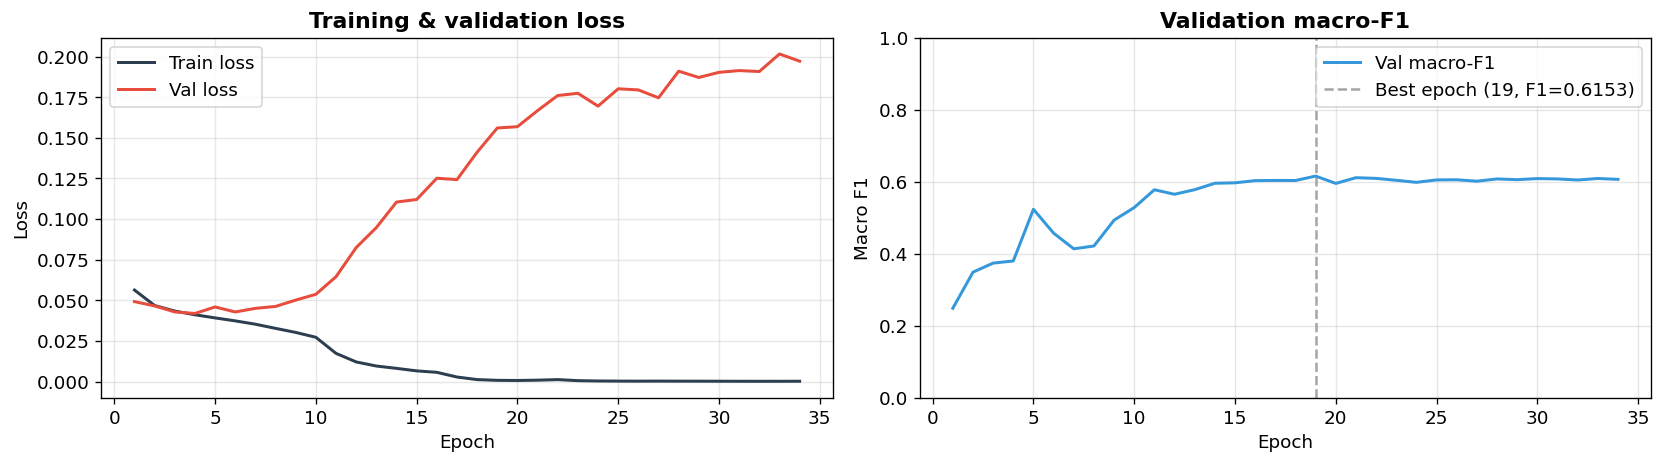

In [10]:
epochs_ran = list(range(1, len(history['train_loss'])+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train loss', color='#2c3e50', linewidth=1.8)
ax.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='#e74c3c', linewidth=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & validation loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_ran, history['val_f1'], label='Val macro-F1', color='#3498db', linewidth=1.8)
best_ep = int(np.argmax(history['val_f1']))
ax.axvline(best_ep+1, color='grey', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_ep+1}, F1={max(history["val_f1"]):.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
ax.set_title('Validation macro-F1', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 9 · Evaluation

In [11]:
print(f'Test set: {len(test_probs)} samples')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('─'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('─'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')

Test set: 2449 samples
Class   Sensitivity  Specificity   Accuracy       F1
────────────────────────────────────────────────────
MI           0.5930       0.8549     0.7668   0.6309
STTC         0.6840       0.8519     0.7979   0.6853
CD           0.6046       0.9130     0.8203   0.6692
HYP          0.3090       0.9308     0.8297   0.3710
────────────────────────────────────────────────────
Macro        0.5477       0.8876     0.8037   0.5891


## 9b · Threshold tuning

Per-class threshold tuning (val set — no test leakage):
Class   Best thresh    F1@0.50    F1@best
------------------------------------------
MI             0.24     0.6271     0.6648
STTC           0.38     0.6986     0.7128
CD             0.38     0.6859     0.6957
HYP            0.21     0.4497     0.4780


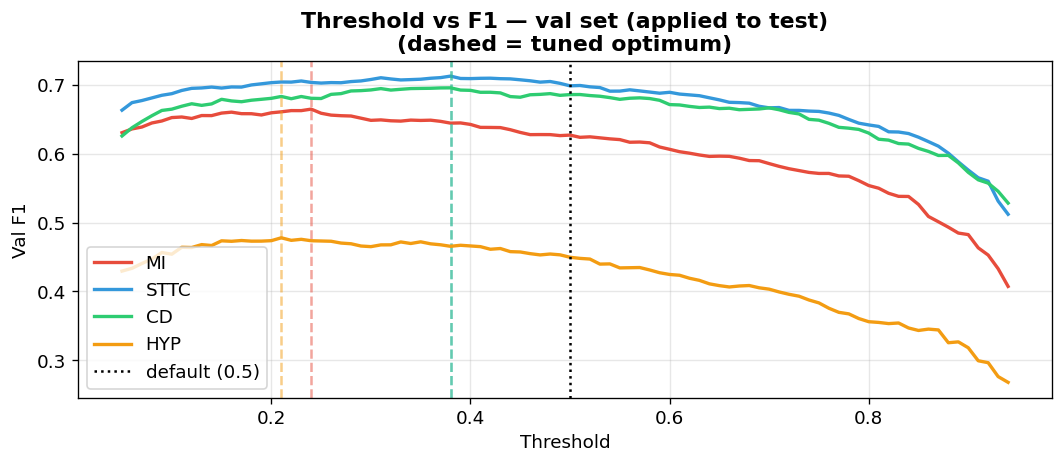


Test — tuned thresholds vs default (0.5):
Class    F1@0.50   F1@tuned     Δ F1
-------------------------------------
MI        0.6309     0.6522 +0.0213
STTC      0.6853     0.6862 +0.0009
CD        0.6692     0.6747 +0.0055
HYP       0.3710     0.4232 +0.0522
-------------------------------------
Macro     0.5891     0.6091 +0.0200


In [12]:
thresholds_grid  = np.arange(0.05, 0.95, 0.01)
best_thresholds  = {}
thresh_f1_curves = {}

print('Per-class threshold tuning (val set — no test leakage):')
print(f'{"Class":<6} {"Best thresh":>12} {"F1@0.50":>10} {"F1@best":>10}')
print('-'*42)
for i, cls in enumerate(CLASS_NAMES):
    f1s    = [f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=t).astype(int), zero_division=0)
              for t in thresholds_grid]
    best_t = thresholds_grid[np.argmax(f1s)]
    f1_50  = f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=0.5).astype(int), zero_division=0)
    best_thresholds[cls]  = best_t
    thresh_f1_curves[cls] = f1s
    print(f'{cls:<6} {best_t:>12.2f} {f1_50:>10.4f} {max(f1s):>10.4f}')

fig, ax = plt.subplots(figsize=(9,4))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for cls, col in zip(CLASS_NAMES, colors):
    ax.plot(thresholds_grid, thresh_f1_curves[cls], label=cls, color=col, linewidth=2)
    ax.axvline(best_thresholds[cls], color=col, linestyle='--', alpha=0.5)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='default (0.5)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Val F1')
ax.set_title('Threshold vs F1 — val set (applied to test)\n(dashed = tuned optimum)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'threshold_tuning.png', bbox_inches='tight')
plt.show()

tuned_arr  = np.array([best_thresholds[c] for c in CLASS_NAMES])
preds_tuned = (test_probs >= tuned_arr).astype(int)
mcm_tuned   = multilabel_confusion_matrix(test_targets.astype(int), preds_tuned)
test_metrics_tuned = {}
for i, cls in enumerate(CLASS_NAMES):
    tn,fp,fn,tp = mcm_tuned[i].ravel()
    test_metrics_tuned[cls] = dict(
        sensitivity=tp/(tp+fn+1e-8), specificity=tn/(tn+fp+1e-8),
        accuracy=(tp+tn)/(tp+tn+fp+fn+1e-8), f1=2*tp/(2*tp+fp+fn+1e-8))
for m in ('sensitivity','specificity','accuracy','f1'):
    test_metrics_tuned[f'macro_{m}'] = np.mean([test_metrics_tuned[c][m] for c in CLASS_NAMES])

print(f'\nTest — tuned thresholds vs default (0.5):')
print(f'{"Class":<6} {"F1@0.50":>9} {"F1@tuned":>10} {"Δ F1":>8}')
print('-'*37)
for cls in CLASS_NAMES:
    d = test_metrics_tuned[cls]['f1'] - test_metrics[cls]['f1']
    print(f'{cls:<6} {test_metrics[cls]["f1"]:>9.4f} {test_metrics_tuned[cls]["f1"]:>10.4f} {d:>+7.4f}')
print('-'*37)
print(f'{"Macro":<6} {test_metrics["macro_f1"]:>9.4f} {test_metrics_tuned["macro_f1"]:>10.4f} '
      f'{test_metrics_tuned["macro_f1"]-test_metrics["macro_f1"]:>+7.4f}')

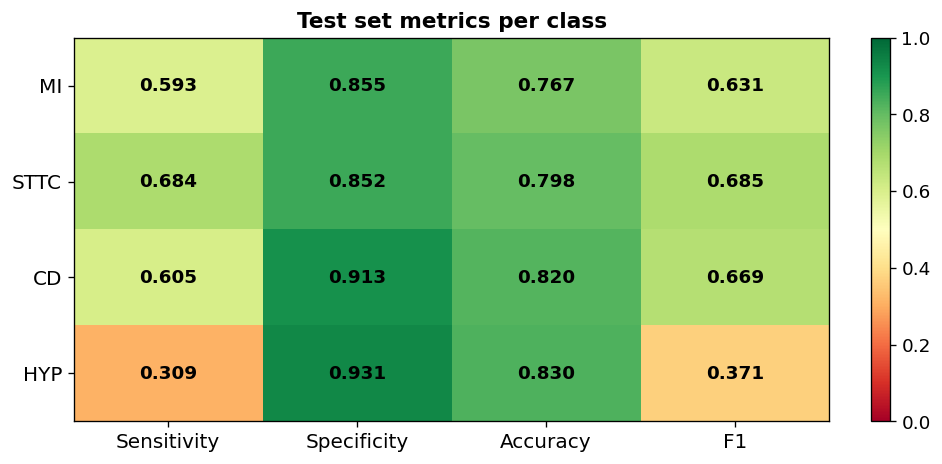

In [13]:
metric_names = ['Sensitivity','Specificity','Accuracy','F1']
metric_keys  = ['sensitivity','specificity','accuracy','f1']
data = np.array([[test_metrics[cls][k] for k in metric_keys] for cls in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(metric_names))); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_yticks(range(len(CLASS_NAMES)));  ax.set_yticklabels(CLASS_NAMES, fontsize=12)
for i in range(len(CLASS_NAMES)):
    for j in range(len(metric_names)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Test set metrics per class', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'metrics_heatmap.png', bbox_inches='tight')
plt.show()

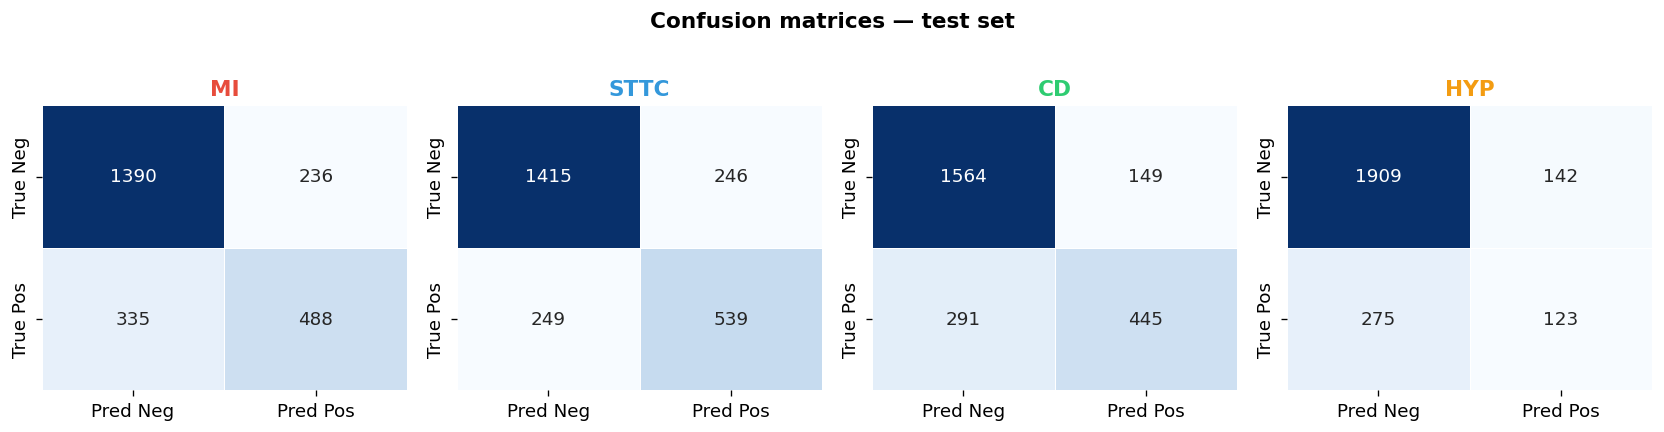

In [14]:
preds_bin = (test_probs >= THRESHOLD).astype(int)
mcm = multilabel_confusion_matrix(test_targets.astype(int), preds_bin)
COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14,3.5))
for i,(cls,ax) in enumerate(zip(CLASS_NAMES,axes)):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg','Pred Pos'], yticklabels=['True Neg','True Pos'],
                cbar=False, linewidths=0.5)
    ax.set_title(cls, fontweight='bold', color=COLORS[i], fontsize=13)
plt.suptitle('Confusion matrices — test set', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10 · XAI — GradCAM on 2D spectrogram

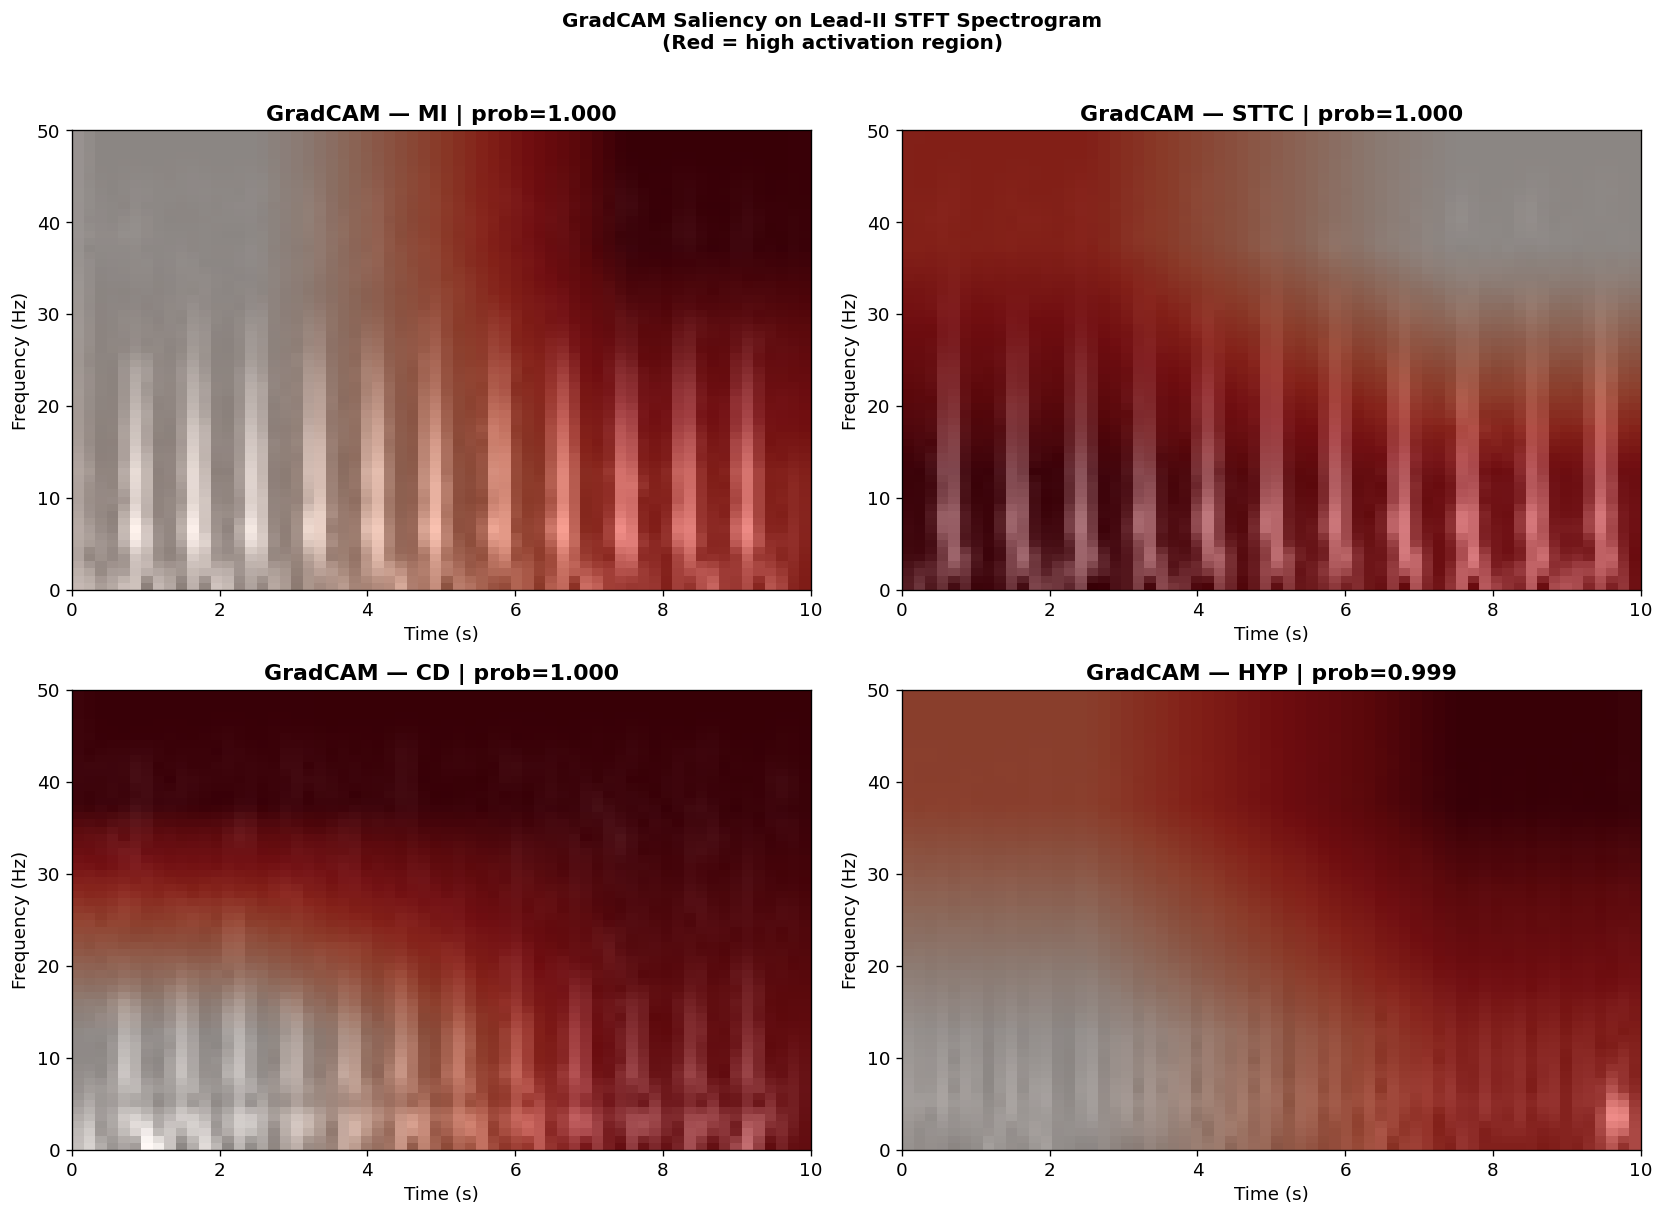

In [15]:
# GradCAM for 2D CNN — temporal-frequency saliency on spectrogram
class GradCAM2D:
    def __init__(self, model, target_layer):
        self.model = model; self.activations = None; self.gradients = None
        self._fh = target_layer.register_forward_hook(lambda m,i,o: setattr(self, 'activations', o.detach()))
        self._bh = target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, x, cls_idx):
        was = self.model.training; self.model.train()
        x = x.requires_grad_(True)
        logits = self.model(x); self.model.zero_grad()
        logits[0, cls_idx].backward()
        if not was: self.model.eval()
        weights = self.gradients.mean(dim=(-2,-1), keepdim=True)  # (1,C,1,1)
        cam = (weights * self.activations).sum(1).squeeze()        # (H',W')
        cam = torch.relu(cam).cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove_hooks(self): self._fh.remove(); self._bh.remove()

# Target: last conv in ResNet layer4
target_layer = model.model.layer4[-1].conv2
grad_cam = GradCAM2D(model, target_layer)
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (cls_idx, cls) in zip(axes.flat, enumerate(CLASS_NAMES)):
    mask = test_targets[:, cls_idx] == 1
    if not mask.any(): ax.set_title(f'{cls}: no samples'); continue
    best_idx = np.argmax(test_probs[mask, cls_idx])
    raw_ecg  = X_test_split[np.where(mask)[0][best_idx]]   # (12, 1000)
    spec     = ecg_to_spec(raw_ecg, img_size=IMG_SIZE)      # (12, 64, 64)
    x_t      = torch.tensor(spec[np.newaxis]).to(DEVICE)

    cam  = grad_cam.generate(x_t, cls_idx)  # (H',W') from layer4
    cam_r = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_r = F.interpolate(cam_r, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam_r = cam_r.squeeze().numpy()

    # Show lead II spectrogram + CAM overlay
    spec_lead = spec[1]   # lead II spectrogram (64,64)
    ax.imshow(spec_lead, origin='lower', aspect='auto', cmap='gray',
              extent=[0,10,0,50])
    ax.imshow(cam_r, origin='lower', aspect='auto', cmap='Reds', alpha=0.55,
              extent=[0,10,0,50])
    ax.set_title(f'GradCAM — {cls} | prob={test_probs[np.where(mask)[0][best_idx], cls_idx]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')

grad_cam.remove_hooks()
plt.suptitle('GradCAM Saliency on Lead-II STFT Spectrogram\n(Red = high activation region)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'xai_gradcam2d.png', bbox_inches='tight')
plt.show()

## 11 · Summary

In [16]:
print('='*60)
print('  FINAL SUMMARY — ResNet2D_ECG')
print('='*60)
print(f'Dataset: {len(X_bal)} samples  (NORM undersampled to {NORM_CAP})')
print(f'Split:   {len(X_train_split)} train / {len(X_val_split)} val / {len(X_test_split)} test')

print()
print('Test performance (default threshold):')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size/1024:7.1f} KB')

  FINAL SUMMARY — ResNet2D_ECG
Dataset: 16347 samples  (NORM undersampled to 4000)
Split:   11474 train / 2424 val / 2449 test

Test performance (default threshold):
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5930       0.8549     0.7668   0.6309
STTC         0.6840       0.8519     0.7979   0.6853
CD           0.6046       0.9130     0.8203   0.6692
HYP          0.3090       0.9308     0.8297   0.3710
----------------------------------------------------
Macro        0.5477       0.8876     0.8037   0.5891

  best_model.pt                                 43850.9 KB
  confusion_matrices.png                           35.8 KB
  metrics_heatmap.png                              44.5 KB
  threshold_tuning.png                             72.5 KB
  training_curves.png                              71.3 KB
  xai_gradcam2d.png                               111.9 KB
